In [1]:
import scipy.io as sio
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

dir = os.getcwd()+"/data/"
data = sio.loadmat(dir+"nn_data.mat")
patterns = data['w']
phases = data['phase']

nsamps,ny,nx = np.shape(patterns)
perm = np.random.permutation(int(.9*nsamps))
training_samples = perm[:int(.8*nsamps)]
val_samples = perm[int(.8*nsamps):]
test_samples = np.arange(int(.9*nsamps), nsamps)

training_data = {'w': patterns[training_samples,:,:],
                 'theta': phases[training_samples,::4,::4]}
val_data = {'w': patterns[val_samples,:,:],
            'theta': phases[val_samples,::4,::4]}
test_data = {'w': patterns[test_samples,:,:],
            'theta': phases[test_samples,::4,::4]}

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

pat_train = training_data['w']
pat_test = test_data['w']
pat_val = val_data['w']
pat_train = pat_train.astype('float32')
pat_test = pat_test.astype('float32')
pat_val = pat_val.astype('float32')
print(pat_train.shape)
print(pat_test.shape)
print(pat_val.shape)

phase_train = training_data['theta']
phase_test = test_data['theta']
phase_val = val_data['theta']
phase_train = phase_train.astype('float32')
phase_test = phase_test.astype('float32')
phase_val = phase_val.astype('float32')
print(phase_train.shape)
print(phase_test.shape)
print(phase_val.shape)

2024-04-17 00:24:40.748645: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


(1200, 128, 128)
(150, 128, 128)
(150, 128, 128)
(1200, 32, 32)
(150, 32, 32)
(150, 32, 32)


In [7]:
_, dimy, dimx = phase_train.shape
class PhaseExtract(Model):
  def __init__(self, dimx, dimy):
    super(PhaseExtract, self).__init__()
    self.dimx = dimx
    self.dimy = dimy
    flatnum = int(dimx*dimy)
    self.phase = tf.keras.Sequential([
      layers.Flatten(),
      # layers.Dense(int(5*flatnum), activation='linear'),
      # layers.Dense(int(4*flatnum), activation='linear'),
      # layers.Dense(int(3*flatnum), activation='tanh'),
      # layers.Dense(int(2*flatnum), activation='linear'),
      # layers.Dense(flatnum, activation='tanh'),
      layers.Dense(512, activation='linear'),
      layers.Dense(512, activation='linear'),
      layers.Dense(512, activation='sigmoid'),
      layers.Dense(256, activation='linear'),
      layers.Dense(256, activation='linear'),
      layers.Dense(256, activation='sigmoid'),
      layers.Dense(256, activation='linear'),
      layers.Dense(256, activation='relu'),
      layers.Dense(512, activation='relu'),
      layers.Dense(flatnum, activation='linear'),
      layers.Reshape((dimy, dimx))
    ])

  def call(self, x):
    phase = self.phase(x)
    return phase

coarse_phase = PhaseExtract(dimx,dimy)


In [9]:
#coarse_phase.compile(optimizer='adam', loss=losses.MeanSquaredError())
coarse_phase.compile(optimizer=tf.keras.optimizers.Adam(1e-6),loss=losses.MeanSquaredError())
coarse_phase.fit(pat_train, phase_train,
                epochs=10000,
                batch_size=120,
                shuffle=True,
                validation_data=(pat_test, phase_test))

Epoch 1/10000
10/10 [==============================] - 2s 84ms/step - loss: 2.4184 - val_loss: 3.2526
Epoch 2/10000
10/10 [==============================] - 1s 68ms/step - loss: 2.4127 - val_loss: 3.2382
Epoch 3/10000
10/10 [==============================] - 1s 61ms/step - loss: 2.4078 - val_loss: 3.2379
Epoch 4/10000
10/10 [==============================] - 1s 64ms/step - loss: 2.4030 - val_loss: 3.2255
Epoch 5/10000
10/10 [==============================] - 1s 79ms/step - loss: 2.3984 - val_loss: 3.2228
Epoch 6/10000
10/10 [==============================] - 1s 61ms/step - loss: 2.3940 - val_loss: 3.2147
Epoch 7/10000
10/10 [==============================] - 1s 61ms/step - loss: 2.3897 - val_loss: 3.2124
Epoch 8/10000
10/10 [==============================] - 1s 59ms/step - loss: 2.3855 - val_loss: 3.2004
Epoch 9/10000
10/10 [==============================] - 1s 71ms/step - loss: 2.3814 - val_loss: 3.2032
Epoch 10/10000
10/10 [==============================] - 1s 61ms/step - loss: 2.377

In [10]:
coarse_phase.phase.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 16384)             0         
                                                                 
 dense_19 (Dense)            (None, 512)               8389120   
                                                                 
 dense_20 (Dense)            (None, 512)               262656    
                                                                 
 dense_21 (Dense)            (None, 512)               262656    
                                                                 
 dense_22 (Dense)            (None, 256)               131328    
                                                                 
 dense_23 (Dense)            (None, 256)               65792     
                                                                 
 dense_24 (Dense)            (None, 256)              

In [11]:
unseen_phases = coarse_phase.phase(pat_val).numpy()

time step:  37
(32, 32)
time step:  88
(32, 32)
time step:  27
(32, 32)
time step:  26
(32, 32)
time step:  51
(32, 32)
time step:  143
(32, 32)
time step:  34
(32, 32)
time step:  88
(32, 32)
time step:  31
(32, 32)
time step:  108
(32, 32)


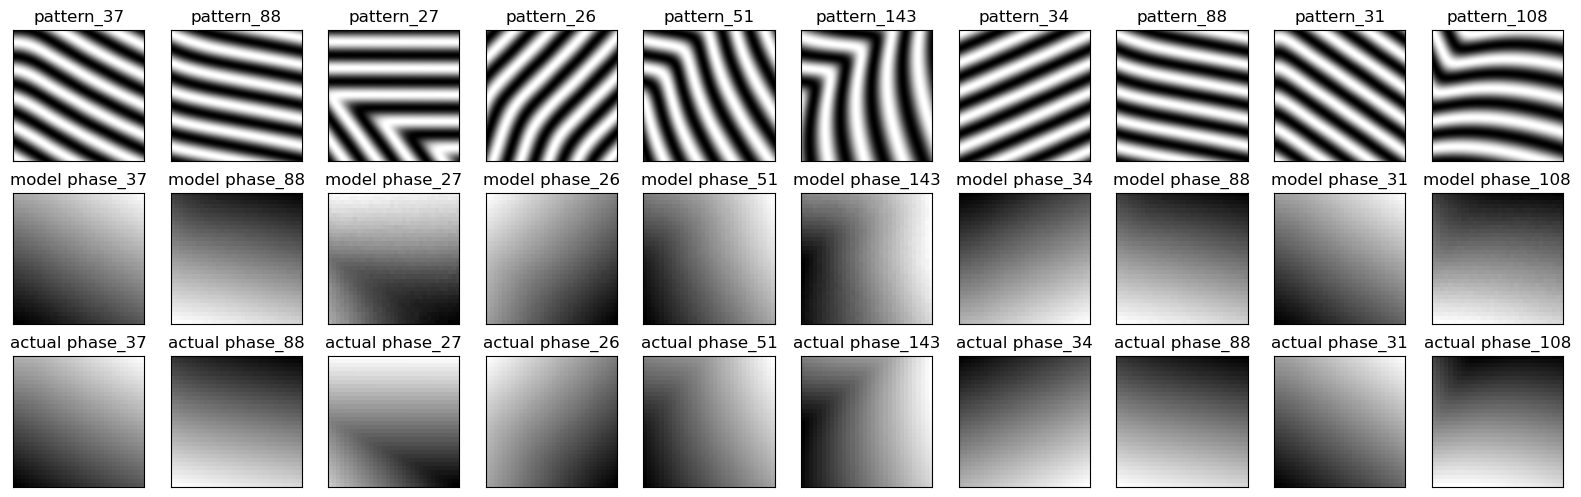

In [13]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
  idx = np.random.randint(1,149)
  print("time step: ",idx)
  # display original
  ax = plt.subplot(3, n, i + 1)
  plt.imshow(pat_val[idx])
  plt.title("pattern"+"_"+str(idx))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reshaped encoded
  ax = plt.subplot(3, n, i + 1 + n)
  plt.imshow(unseen_phases[idx])
  plt.title("model phase"+"_"+str(idx))
  plt.gray()
  print(np.shape(unseen_phases[idx]))
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(3, n, i + 1 + 2*n)
  plt.imshow(phase_val[idx])
  plt.title("actual phase"+"_"+str(idx))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)